# Tarea 9 — Machine Learning
## ¿Quién gana más de 50,000 dólares al año?
### Lasso + Árboles + Random Forest

---

En clase predijimos el **default** de clientes de tarjeta de crédito en Taiwan.
Hoy vas a repetir **exactamente la misma receta** con otro problema y otros datos.

**No hay nada nuevo en esta tarea.** Todo lo que necesitas está en el notebook de la clase 9.
Si te atoras, ábrelo y busca la celda equivalente.

### El problema

El **Census Bureau** de Estados Unidos levantó una encuesta a 48,842 personas en 1994.
Queremos predecir, a partir de sus características (edad, escolaridad, horas trabajadas,
estado civil…), si la persona **gana más de 50,000 USD al año**.

Variable objetivo: `ingreso_alto` — 1 si gana >50K, 0 si gana ≤50K.

Otra vez es **clasificación binaria**, y otra vez está **desbalanceada**.

### Cómo trabajar esta tarea

Vas a ver dos tipos de cosas:

- Celdas de código con `___` → **complétalas**.
- Preguntas marcadas con ✍️ → **respóndelas en la celda de texto de abajo**.

Las preguntas ✍️ casi siempre van **ANTES** de correr el código. Eso es a propósito:
la idea es que **adivines** el resultado y luego veas si le atinaste. Equivocarte ahí
no baja puntos — lo que se califica es que hayas escrito tu intuición antes de ver
la respuesta. Un buen modelador no es el que nunca se equivoca, es el que tiene una
expectativa clara y se da cuenta cuando la realidad no la cumple.

---

## Paso 0 — Instalación e imports

(Esta celda ya está completa — solo córrela.)

In [2]:
%%capture
pip install ucimlrepo scikit-learn pandas numpy matplotlib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_auc_score, roc_curve
)

np.random.seed(42)
print("Librerías cargadas ✓")

Librerías cargadas ✓


---
# Parte 1 — Cargar los datos y mirar el desbalance

En clase usamos `fetch_ucirepo(id=350)` para el default de tarjetas.
El identificador de este dataset (Adult / Census Income) es **`id=2`**.

In [4]:
# id=2 = Adult / Census Income, del UCI Machine Learning Repository
dataset = fetch_ucirepo(id=2)

X     = dataset.data.features
y_raw = dataset.data.targets

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y_raw.shape}")
print("\nVariables disponibles:")
print(list(X.columns))

Dimensiones de X: (48842, 14)
Dimensiones de y: (48842, 1)

Variables disponibles:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


In [5]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [6]:
# descripción de cada variable (igual que en clase)
print(dataset.variables[['name', 'description']].to_string())

              name                                                                                                                                                                                                                                                                                                                                                                                                                      description
0              age                                                                                                                                                                                                                                                                                                                                                                                                                              N/A
1        workclass                                                                                                              

La variable objetivo viene como **texto**: `'<=50K'` o `'>50K'`.
Los modelos necesitan números, así que la convertimos a 0/1.

Ojo con un detalle sucio de estos datos: algunos valores traen un punto al final
(`'>50K.'`). Es un error de captura del archivo original. `.str.strip()` quita
espacios y `.str.rstrip('.')` quita el punto — las mismas herramientas de limpieza
de texto que usamos con los comentarios de YouTube.

In [7]:
# .squeeze() convierte un DataFrame de una sola columna en una Serie
income = y_raw.squeeze().str.strip().str.rstrip('.')

print("Valores únicos después de limpiar:", sorted(income.unique()))

# (income == '>50K') da True/False → .astype(int) lo vuelve 1/0
y = (income == '>50K').astype(int)

Valores únicos después de limpiar: ['<=50K', '>50K']


**✍️ Pregunta 1 (antes de correr la celda de abajo).**

En clase, el 22% de los clientes hacía default. Aquí la pregunta es cuánta gente gana más de 50 mil dólares al año en el Estados Unidos de 1994.

Sin correr nada: ¿qué porcentaje crees que gana >50K? Escribe tu número.
Y una segunda pregunta: si un modelo **siempre** predijera "gana ≤50K", ¿qué accuracy tendría?

*Tu respuesta:*

> Yo personalmente creería que aproximadamente un 25%. Por el otro lado, si un modelo siempre predijera "gana <= 50 K, tendría un accuracy de 76%.

---

**Ejercicio 1.** Completa el código para ver la distribución de la variable objetivo.

In [9]:
conteo = y.value_counts()
print("Distribución de la variable objetivo:")
print(conteo)

pct_altos = conteo[1] / len(y) * 100   # porcentaje de personas que ganan >50K
pct_bajos = conteo[0] / len(y) * 100   # porcentaje de personas que ganan <=50K

print(f"\nPorcentaje que gana >50K : {pct_altos:.1f}%")
print(f"Porcentaje que gana <=50K: {pct_bajos:.1f}%")

Distribución de la variable objetivo:
income
0    37155
1    11687
Name: count, dtype: int64

Porcentaje que gana >50K : 23.9%
Porcentaje que gana <=50K: 76.1%


---
# Parte 2 — Crear variables nuevas

Igual que en clase, no modelamos con las variables crudas: primero construimos
variables que capturen mejor la información.

Las herramientas son **las mismas tres** de la clase:

| Herramienta | Qué hace | Ejemplo de la clase |
|---|---|---|
| `.apply(lambda x: ...)` | aplica una función a cada valor de la columna | limpiar `EDUCATION` |
| `np.log1p(x)` | `log(x + 1)`, comprime distribuciones sesgadas | `log_limite` |
| `np.where(cond, a, b)` | el `ifelse()` de R | `ratio_utilizacion` |

In [11]:
df = X.copy()
df['ingreso_alto'] = y.values

**Ejercicio 2.** Crea las seis variables nuevas.

- `sexo_binario`: 1 si `sex` es `'Male'`, 0 si no → usa `.apply()` con una lambda
- `casado`: 1 si `marital-status` es `'Married-civ-spouse'`, 0 si no → igual
- `log_ganancia`: log de `capital-gain` → usa `np.log1p()`
- `log_perdida`: log de `capital-loss` → igual
- `ganancia_neta`: `capital-gain` menos `capital-loss`
- `tiene_ganancia`: 1 si `capital-gain` es mayor a 0, 0 si no → usa `np.where()`

*Tip: `capital-gain` tiene un guion en el nombre, así que hay que escribirlo como
`df['capital-gain']` — no funciona `df.capital-gain`.*

In [12]:
df['sexo_binario']   = df['sex'].apply(lambda s: 1 if s == 'Male' else 0)
df['casado']         = df['marital-status'].apply(lambda s: 1 if s == 'Married-civ-spouse' else 0)
df['log_ganancia']   = np.log1p(df['capital-gain'])
df['log_perdida']    = np.log1p(df['capital-loss'])
df['ganancia_neta']  = df['capital-gain'] - df['capital-loss']
df['tiene_ganancia'] = np.where(df['capital-gain'] > 0, 1, 0)


nuevas = ['sexo_binario', 'casado', 'log_ganancia', 'log_perdida',
          'ganancia_neta', 'tiene_ganancia']
df[nuevas].describe().round(3)

,sexo_binario,casado,log_ganancia,log_perdida,ganancia_neta,tiene_ganancia
count,48842.000,48842.000,48842.000,48842.000,48842.000,48842.000
mean,0.668,0.458,0.729,0.351,991.565,0.083
std,0.471,0.498,2.445,1.586,7475.550,0.275
min,0.000,0.000,0.000,0.000,-4356.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000
50%,1.000,0.000,0.000,0.000,0.000,0.000
75%,1.000,1.000,0.000,0.000,0.000,0.000
max,1.000,1.000,11.513,8.380,99999.000,1.000


Ahora definimos la lista de variables del modelo.

Fíjate que metimos `fnlwgt` a propósito. Es el *final weight* de la encuesta: un peso
muestral que el Census usa para expandir la muestra a la población. **No tiene nada
que ver con el ingreso de la persona.** Está ahí como control — a ver si los modelos
se dan cuenta solos de que no sirve.

In [13]:
FEATURES = [
    # variables originales numéricas
    'age', 'education-num', 'hours-per-week', 'fnlwgt',
    # variables nuevas
    'sexo_binario', 'casado', 'log_ganancia', 'log_perdida',
    'ganancia_neta', 'tiene_ganancia'
]

X_model = df[FEATURES]
y_model = df['ingreso_alto']

print(f"{len(FEATURES)} variables, {len(X_model)} observaciones")

10 variables, 48842 observaciones


---
# Parte 3 — Train/test split y escalado

Copia la receta de la clase. Recuerda los dos detalles que explicamos:

1. `stratify=y_model` → mantiene el mismo % de "ingreso alto" en train y en test.
2. El scaler se ajusta **solo con train** (`.fit_transform`) y a test solo se le
   aplica (`.transform`). Ajustarlo con test sería filtrar información.

**Ejercicio 3.** Completa el split y el escalado.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model,
    test_size    = 0.2,   # 20% para test
    stratify     = y_model,
    random_state = 42
)

print(f"Train: {X_train.shape[0]} observaciones")
print(f"Test:  {X_test.shape[0]} observaciones")
print(f"\n% de ingreso alto en train: {y_train.mean()*100:.1f}%")
print(f"% de ingreso alto en test:  {y_test.mean()*100:.1f}%")

Train: 39073 observaciones
Test:  9769 observaciones

% de ingreso alto en train: 23.9%
% de ingreso alto en test:  23.9%


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # ajustar Y transformar train
X_test_scaled  = scaler.transform(X_test)  # solo transformar test

# verificación: la primera columna es 'age'
print(f"Media de age en train (debe ser ~0): {X_train_scaled[:, 0].mean():.4f}")
print(f"Std de age en train (debe ser ~1):   {X_train_scaled[:, 0].std():.4f}")

Media de age en train (debe ser ~0): 0.0000
Std de age en train (debe ser ~1):   1.0000


---
# Parte 4 — Lasso

**✍️ Pregunta 2 (antes de correr).**

Vamos a entrenar un Lasso con `C=0.01` (regularización fuerte). Lasso manda a **cero**
los coeficientes de las variables que no aportan.

De estas 10 variables, ¿cuál crees que Lasso va a mandar a cero?
Y de las que sobrevivan, ¿cuál crees que va a tener el coeficiente **más grande**?

```
age · education-num · hours-per-week · fnlwgt · sexo_binario
casado · log_ganancia · log_perdida · ganancia_neta · tiene_ganancia
```

*Tu respuesta:*

> Considero que la variable que mandaría a 0, sería la de fnlwgt, ya que esta la metimos para control y no representa una significancia para este modelo, por el otro lado, considero que el coeficiente más grande sería el de ganancia neta, ya que nos arrojaría un coeficiente sobre un valor total

---

**Ejercicio 4.** Entrena el Lasso y saca los coeficientes.

In [17]:
lasso = LogisticRegression(
    penalty      = 'l1',
    C            = 0.01,
    solver       = 'liblinear',
    max_iter     = 1000,
    random_state = 42
)

lasso.fit(X_train_scaled, y_train)   # entrena el modelo (¿con X_train o con X_train_scaled?)

coeficientes = pd.Series(
    lasso.coef_[0],
    index=FEATURES
).sort_values(key=abs, ascending=False)

print("Coeficientes Lasso (0 = variable eliminada):")
print(coeficientes.round(4))
print(f"\nVariables eliminadas: {(coeficientes == 0).sum()} de {len(FEATURES)}")

Coeficientes Lasso (0 = variable eliminada):
ganancia_neta     1.9038
casado            1.1373
education-num     0.8905
hours-per-week    0.3605
age               0.3408
log_perdida       0.3332
fnlwgt            0.0377
sexo_binario      0.0276
tiene_ganancia   -0.0065
log_ganancia      0.0000
dtype: float64

Variables eliminadas: 1 de 10


**Ejercicio 5.** Grafica los coeficientes. Cópiale la gráfica a la clase 9.

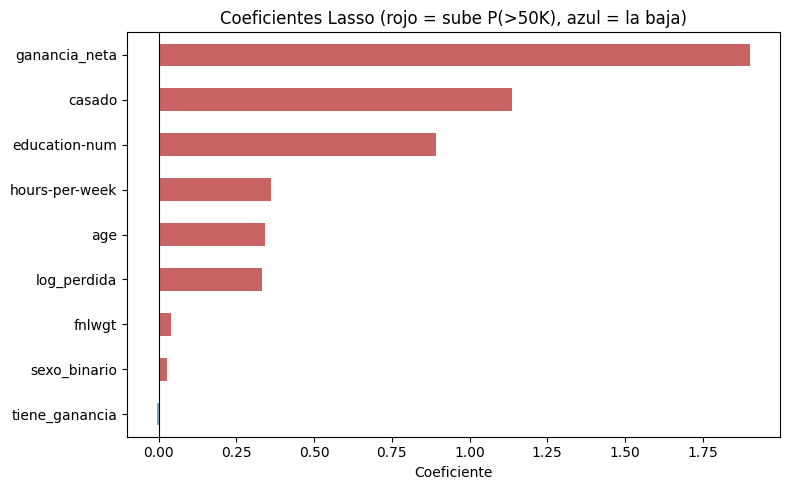

In [18]:
coef_no_cero = coeficientes[coeficientes != 0].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colores = ['firebrick' if v > 0 else 'steelblue' for v in coef_no_cero.values]

coef_no_cero.plot (kind='barh', ax=ax, color=colores, alpha=0.7)   # barras horizontales de coef_no_cero

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes Lasso (rojo = sube P(>50K), azul = la baja)', fontsize=12)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

---
# Parte 5 — Evaluar: la trampa del accuracy

Ya sabes cómo termina esta historia: el dataset está desbalanceado, así que **el accuracy
solo, miente**. Vamos a demostrarlo otra vez con estos datos.

**Ejercicio 6.** Saca las predicciones y la matriz de confusión del Lasso.

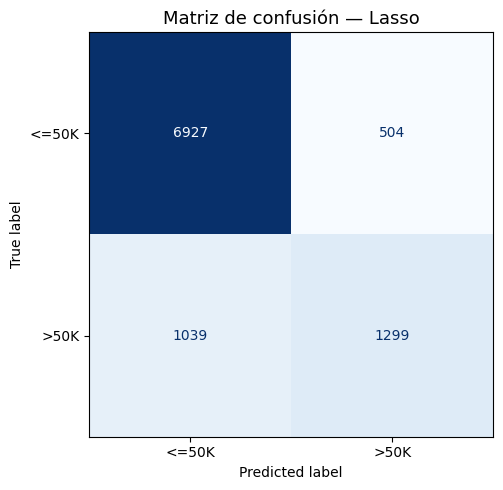

Verdaderos Negativos (TN):  6927
Falsos Positivos     (FP):   504
Falsos Negativos     (FN):  1039
Verdaderos Positivos (TP):  1299

De cada 100 personas que SÍ ganan >50K, el modelo detectó 56


In [19]:
y_pred_lasso = lasso.predict(X_test_scaled)   # predice la CLASE (0 o 1) en el test
y_prob_lasso = lasso.predict_proba(X_test_scaled)[:, 1] # predice la PROBABILIDAD de la clase 1

cm_lasso = confusion_matrix(y_test, y_pred_lasso)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix = cm_lasso,
    display_labels   = ['<=50K', '>50K']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Lasso', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_lasso.ravel()   # ravel() aplana la matriz 2x2 en 4 números

print(f"Verdaderos Negativos (TN): {tn:>5}")
print(f"Falsos Positivos     (FP): {fp:>5}")
print(f"Falsos Negativos     (FN): {fn:>5}")
print(f"Verdaderos Positivos (TP): {tp:>5}")
print(f"\nDe cada 100 personas que SÍ ganan >50K, el modelo detectó {tp/(tp+fn)*100:.0f}")

In [20]:
print("Reporte de clasificación — Lasso:")
print(classification_report(y_test, y_pred_lasso, target_names=['<=50K', '>50K']))

auc_lasso = roc_auc_score(y_test, y_prob_lasso)
print(f"AUC-ROC: {auc_lasso:.4f}")

Reporte de clasificación — Lasso:
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      7431
        >50K       0.72      0.56      0.63      2338

    accuracy                           0.84      9769
   macro avg       0.80      0.74      0.76      9769
weighted avg       0.83      0.84      0.83      9769

AUC-ROC: 0.8945


**✍️ Pregunta 3 (antes de correr).**

Vuelve a tu respuesta de la Pregunta 1. Ahí calculaste el accuracy de un modelo
que **siempre** predice "≤50K", sin mirar ni una sola variable.

En el reporte de arriba está el accuracy del Lasso. Compáralos.

1. ¿Cuál es más alto y por cuánto?
2. Si la diferencia es tan chica, ¿para qué sirvió entrenar el Lasso? ¿Qué métrica
   sí distingue a los dos modelos, y por qué?

*Tu respuesta:*

> 1.- en este caso el más alto es el de 0.84, mientras que el modelo calculado con anticipación era de 76, por lo que solo hay una diferencia de 8.

> 2.- en este caso, el modelo con lasso tiene una mejor precisión al detectar a las personas con ingreso alto, mientras que el anterior modelo al tener un F1 de cero, no detectaba a nadie como persona de ingreso alto.


---

**Ejercicio 7.** Compara el Lasso contra el modelo tonto.

In [21]:
# el modelo tonto: siempre predice 'gana <=50K'
y_siempre_cero = np.zeros(len(y_test))

acc_lasso = accuracy_score(y_test, y_pred_lasso)
f1_lasso  = f1_score(y_test, y_pred_lasso)
acc_tonto = accuracy_score(y_test, y_siempre_cero)
f1_tonto  = f1_score(y_test, y_siempre_cero)


print(f"{'Modelo':<32} {'Accuracy':>10} {'F1 (>50K)':>12}")
print("-" * 56)
print(f"{'Lasso':<32} {acc_lasso:>10.3f} {f1_lasso:>12.3f}")
print(f"{'Siempre predice <=50K':<32} {acc_tonto:>10.3f} {f1_tonto:>12.3f}")

Modelo                             Accuracy    F1 (>50K)
--------------------------------------------------------
Lasso                                 0.842        0.627
Siempre predice <=50K                 0.761        0.000


---
# Parte 6 — Overfitting

Esta es **la gráfica más importante de la clase 9**. Vamos a reproducirla aquí.

La idea: entrenar árboles cada vez más profundos y medir el AUC en train y en test
**al mismo tiempo**.

**✍️ Pregunta 4 (antes de correr).**

Vas a entrenar árboles de profundidad 1, 2, 3, …, 25.

1. ¿Qué va a hacer la curva de **train** conforme aumenta la profundidad?
2. ¿Y la de **test**?
3. ¿En qué profundidad crees que el test toca su punto máximo?

*Tu respuesta:*

> 1. La curva unicamente va a subir, lo que no representa datos relevantes.
2. De la misma forma que train, test también va a subir, sin embargo, en este caso va a regresar cuando toque el punto más alto, es decir, pasará del punto más alto, hasta el más bajo, provocando que cada nivel extra llegue a empeorar el modelo.
3. El punto máximo de este modelo se considera bajo una profundidad de 7 u 8 aproximadamente (dado que el test nos arrojó 0.906).

---

**Ejercicio 8.** Completa el loop.

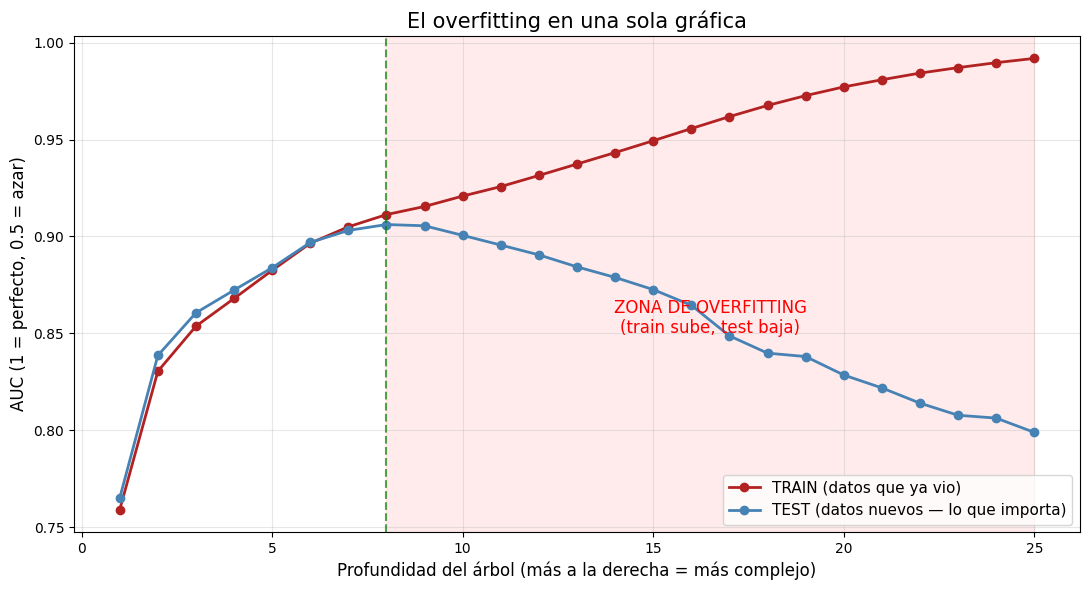

Mejor profundidad según TEST: 8
AUC máximo en TRAIN: 0.992
AUC máximo en TEST:  0.906
En profundidad 25 → train: 0.992 | test: 0.799


In [22]:
profundidades = range(1, 26)
auc_train = []
auc_test  = []

for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=42)
    arbol.fit(X_train, y_train) # entrena el árbol (los árboles NO necesitan escalado)

    auc_train.append(roc_auc_score(y_train, arbol.predict_proba(X_train)[:, 1]))   # AUC en train
    auc_test.append(roc_auc_score(y_test,  arbol.predict_proba(X_test)[:, 1]))    # AUC en test

mejor = list(profundidades)[int(np.argmax(auc_test))]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(list(profundidades), auc_train, 'o-', color='firebrick', lw=2,
        label='TRAIN (datos que ya vio)')
ax.plot(list(profundidades), auc_test, 'o-', color='steelblue', lw=2,
        label='TEST (datos nuevos — lo que importa)')
ax.axvline(mejor, color='green', ls='--', alpha=0.7)
ax.axvspan(mejor, 25, alpha=0.08, color='red')
ax.text((mejor + 25) / 2, 0.85, 'ZONA DE OVERFITTING\n(train sube, test baja)',
        ha='center', color='red', fontsize=12)
ax.set_xlabel('Profundidad del árbol (más a la derecha = más complejo)', fontsize=12)
ax.set_ylabel('AUC (1 = perfecto, 0.5 = azar)', fontsize=12)
ax.set_title('El overfitting en una sola gráfica', fontsize=15)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mejor profundidad según TEST: {mejor}")
print(f"AUC máximo en TRAIN: {max(auc_train):.3f}")
print(f"AUC máximo en TEST:  {max(auc_test):.3f}")
print(f"En profundidad 25 → train: {auc_train[-1]:.3f} | test: {auc_test[-1]:.3f}")

---
# Parte 7 — Random Forest

Un árbol solo tiene alta varianza. La solución: entrenar 200 árboles distintos y
promediar sus votos (**bagging**).

**Ejercicio 9.** Entrena el Random Forest con los mismos hiperparámetros de la clase.

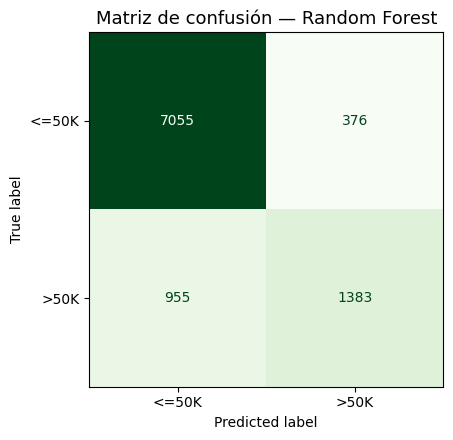

F1 (>50K) — Random Forest: 0.675
AUC-ROC   — Random Forest: 0.9204


In [23]:
rf = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 15,
    min_samples_leaf = 10,
    n_jobs           = -1,
    random_state     = 42
)

rf.fit(X_train, y_train)   # entrénalo (¿escalado o sin escalar?)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]


fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix = confusion_matrix(y_test, y_pred_rf),
    display_labels   = ['<=50K', '>50K']
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de confusión — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

f1_rf  = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"F1 (>50K) — Random Forest: {f1_rf:.3f}")
print(f"AUC-ROC   — Random Forest: {auc_rf:.4f}")

**✍️ Pregunta 5 (antes de correr).**

Ahora vamos a ver qué variables usa más el bosque.

¿Crees que el ranking va a ser el mismo que el de los coeficientes del Lasso
(Ejercicio 4)? ¿Por qué sí o por qué no?

Y la pregunta que de verdad importa: **¿dónde va a quedar `fnlwgt`?** Acuérdate de que
es el peso muestral de la encuesta y no tiene ninguna relación con el ingreso.
¿Va a quedar hasta abajo, en cero?

*Tu respuesta:*

> 1. Desde mi perspectiva, no, ya que hay variables importantes que aparecen en ambos modelos, pero el orden cambia, ya que Lasso y Random Forest miden la importancia de manera diferente. Lasso suele eliminar variables redundantes, pero Random Forest reparte la importancia entre ellas, por lo que cambiaría significativamente.
2. No creo que fnlwgt quede en cero o hasta abajo, ya que aunque no está relacionada con el ingreso, sí tiene importancia, ya que se tienen muchísimos valores diferentes y se puede llegar a tener valores capturados que contengan ruido.

---

**Ejercicio 10.** Grafica las importancias del Random Forest.

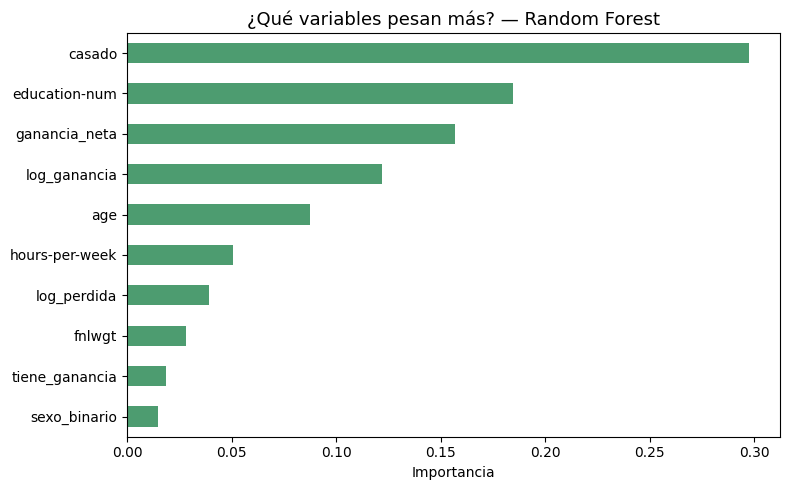

casado            0.2975
education-num     0.1844
ganancia_neta     0.1567
log_ganancia      0.1218
age               0.0877
hours-per-week    0.0508
log_perdida       0.0390
fnlwgt            0.0282
tiene_ganancia    0.0188
sexo_binario      0.0150
dtype: float64


In [24]:
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind='barh', ax=ax, color='seagreen', alpha=0.85)  # barras horizontales de importancias

ax.set_title('¿Qué variables pesan más? — Random Forest', fontsize=13)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

print(importancias.sort_values(ascending=False).round(4))

---
# Parte 8 — Los dos modelos, lado a lado

**Ejercicio 11.** Dibuja la curva ROC de los dos modelos en la misma gráfica.

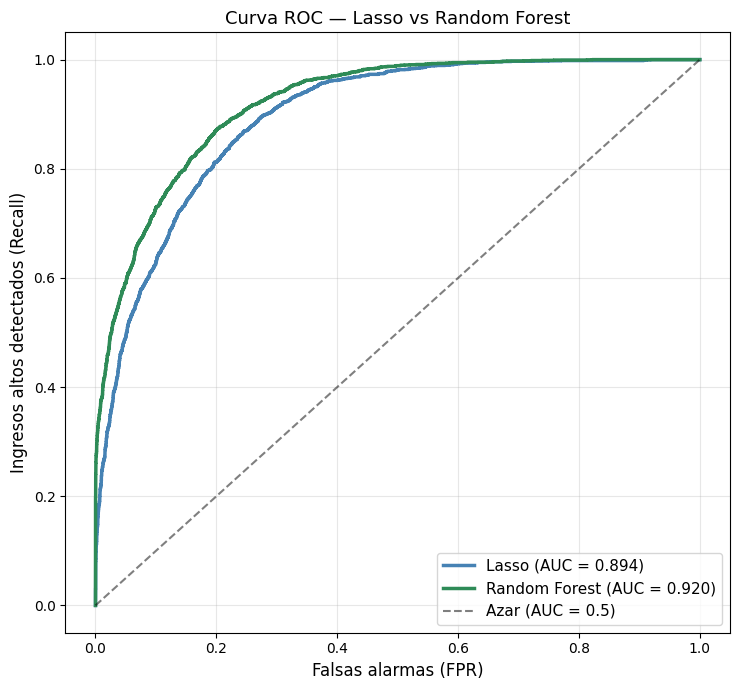

In [25]:
fig, ax = plt.subplots(figsize=(7.5, 7))

modelos_roc = [
    ('Lasso',         y_prob_lasso, 'steelblue'),
    ('Random Forest', y_prob_rf,    'seagreen'),
]

for nombre, prob, color in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test, prob)          # calcula la curva ROC
    auc = roc_auc_score(y_test, prob)                  # calcula el AUC
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{nombre} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar (AUC = 0.5)')
ax.set_xlabel('Falsas alarmas (FPR)', fontsize=12)
ax.set_ylabel('Ingresos altos detectados (Recall)', fontsize=12)
ax.set_title('Curva ROC — Lasso vs Random Forest', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()